## 시간대별 이용객 중첩에 따른 시설 혼잡도 분석
- 교통약자 이용 비중이 높은 시간대와 일반 승객 피크 시간대의 ‘시설 혼잡도’차이는 어떠한가?
- 교통약자 주 이용 시간대와 일반 승객 피크 시간대가 겹친다면, 교통약자의 시설 혼잡도는 기하급수적으로 상승할 것이다.

In [25]:
import numpy as np
import pandas as pd
import re
import folium
import json
import requests
from folium.plugins import HeatMap
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import plotly.express as px

In [26]:
# 데이터 로드
df_total = pd.read_csv('../../data/raw/일반(전체)_집중관리_50개역.csv', encoding='cp949')
df_senior = pd.read_csv('../../data/raw/노인승객_집중관리_50개역.csv', encoding='cp949')
df_cong = pd.read_csv('../../data/raw/혼잡도_집중관리_50개역.csv', encoding='cp949')

In [27]:
# 전처리: 승하차 합계 계산
time_cols = [col for col in df_cong.columns if '시간대' in col or '이전' in col or '이후' in col]

In [28]:
# [전체 데이터] 역별 시간대 합계 및 무임총합 추출
df_total_agg = df_total.groupby('역명').agg({
    **{col: 'sum' for col in time_cols},
    '무임승하차인원': 'first',
    '시간대총합': 'first'
}).reset_index()

In [29]:
# [노인 데이터] 역별 시간대 합계 및 노인총합 추출
df_senior_agg = df_senior.groupby('역명').agg({
    **{col: 'sum' for col in time_cols},
    '시간대총합': 'first'
}).rename(columns={'시간대총합': '노인총합'}).reset_index()

In [30]:
# 데이터 병합
df_final = pd.merge(df_total_agg, df_senior_agg, on='역명', suffixes=('_전체', '_노인'))
df_final = pd.merge(df_final, df_cong, on='역명')

In [31]:
# 시간대별 교통약자 추정 및 분석
analysis_list = []
for _, row in df_final.iterrows():
    # 기타 교통약자(장애인, 유공자 등) 총량 계산
    etc_weak_total = row['무임승하차인원'] - row['노인총합']
    if etc_weak_total < 0: etc_weak_total = 0

    for t_col in time_cols:
        total_p = row[f'{t_col}_전체']
        senior_p = row[f'{t_col}_노인']

        # 노인 이동 패턴에 따른 기타 교통약자 시간대별 배분 (노인 인원 비중만큼 배분)
        senior_pattern_ratio = (senior_p / row['노인총합']) if row['노인총합'] > 0 else 0
        etc_weak_p = etc_weak_total * senior_pattern_ratio

        # 최종 정의된 시간대별 교통약자 (노인 + 추정된 기타 무임)
        total_weak_p = senior_p + etc_weak_p

        # 가설 검증용 지표
        weak_ratio = (total_weak_p / total_p * 100) if total_p > 0 else 0
        cong_v = row[t_col]
        cong_per_1k = (cong_v / (total_p / 1000)) if total_p > 0 else 0

        analysis_list.append({
            '역명': row['역명'],
            '시간대': t_col,
            '전체인원': total_p,
            '교통약자인원(추정)': round(total_weak_p, 0),
            '시간대별_교통약자비중': round(weak_ratio, 2),
            '혼잡도': cong_v,
            '인원당혼잡지표': round(cong_per_1k, 4)
        })

In [32]:
df_result = pd.DataFrame(analysis_list)
df_result.to_csv('교통약자_시간대별_혼잡도_분석_최종.csv', index=False, encoding='cp949')

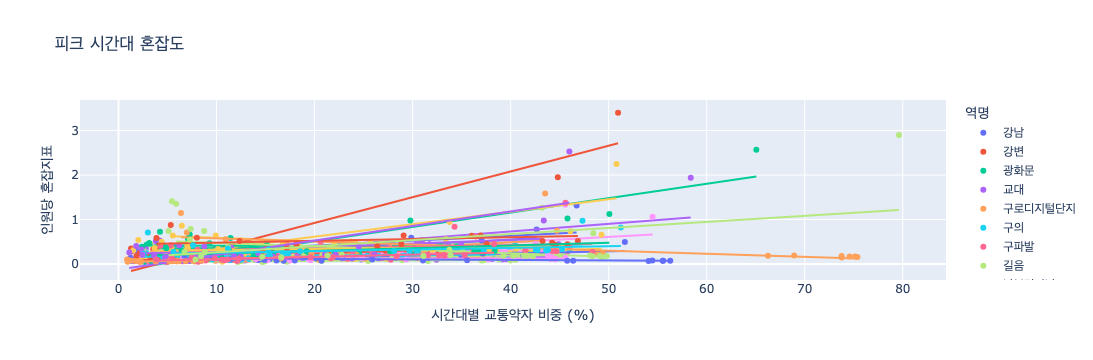

In [33]:
# hover_name: 마우스 올리면 '역명' 표시
# trendline="ols": 최소제곱법(Ordinary Least Squares) 기반 추세선 추가
fig = px.scatter(df_result,
                 x='시간대별_교통약자비중',
                 y='인원당혼잡지표',
                 hover_name='역명',
                 color='역명',
                 trendline="ols",  # 이 부분이 추세선을 그려줍니다
                 title='피크 시간대 혼잡도')

# 그래프 레이아웃 깔끔하게 정리
fig.update_layout(
    xaxis_title="시간대별 교통약자 비중 (%)",
    yaxis_title="인원당 혼잡지표"
)

fig.show()

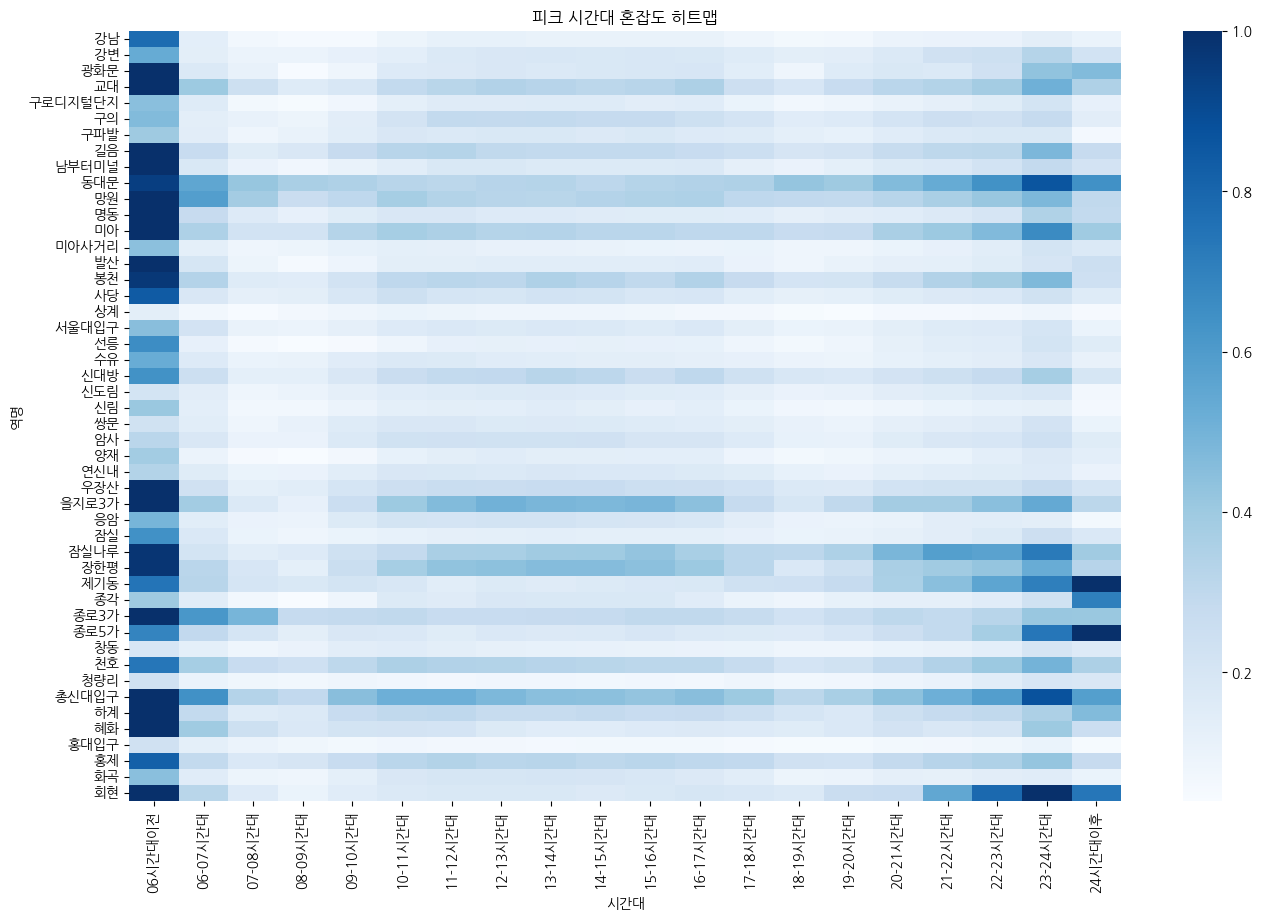

In [34]:
time_order = [
    '06시간대이전', '06-07시간대', '07-08시간대', '08-09시간대', '09-10시간대',
    '10-11시간대', '11-12시간대', '12-13시간대', '13-14시간대', '14-15시간대',
    '15-16시간대', '16-17시간대', '17-18시간대', '18-19시간대', '19-20시간대',
    '20-21시간대', '21-22시간대', '22-23시간대', '23-24시간대', '24시간대이후'
]

# 3. '시간대' 컬럼을 범주형(Categorical) 데이터로 변환하여 순서 고정
df_result['시간대'] = pd.Categorical(df_result['시간대'], categories=time_order, ordered=True)

heatmap_data = df_result.pivot(index='역명', columns='시간대', values='인원당혼잡지표')

plt.figure(figsize=(16, 10))

heatmap_data = heatmap_data[time_order]

sns.heatmap(heatmap_data, cmap='Blues',vmax=1.0)
plt.title('피크 시간대 혼잡도 히트맵')
plt.show()